Hola **Ilich**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# cargar archivos
orders = 'https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv'
catalog = 'https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv'
marketing = 'https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv'

In [3]:
# explorar datasets
orders = pd.read_csv(orders)


In [4]:
catalog = pd.read_csv(catalog)

In [5]:
marketing = pd.read_csv(marketing)

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [6]:
# tu código aquí
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [7]:
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'])

In [8]:
orders['precio_unitario'].describe() 

count    25050.000000
mean       259.305549
std        138.726461
min         20.030000
25%        138.377500
50%        258.715000
75%        380.332500
max        499.960000
Name: precio_unitario, dtype: float64

In [9]:
orders.duplicated().sum()

100

In [10]:
orders = orders.drop_duplicates()

In [11]:
orders = orders.dropna(subset=['pais', 'cantidad', 'precio_unitario', 'monto_descuento'])

In [12]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [13]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


In [14]:
marketing['fecha'] = pd.to_datetime(marketing['fecha'])

In [15]:
marketing['canal'] = marketing['canal'].fillna('unknown')

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, seguiste el paso a paso de tu proyecto de una manera adecuada. Realizando el procesamiento y limpieza ideal para poder tener análisis y hallazgos correctos para luego presentarlos ante el negocio que lo solicitó.
</div>

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [16]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [17]:
# tu código aquí
orders_clean = pd.merge( orders, catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto', how='left' )

In [18]:
orders_clean['costo_total_productos'] = orders_clean['cantidad'] * orders_clean['costo_unitario']

In [19]:
orders_clean.describe()

,cantidad,precio_unitario,monto_descuento,monto_total,costo_unitario,costo_total_productos
count,24650.000000,24650.000000,24650.000000,2.465000e+04,24620.000000,2.462000e+04
mean,7.183976,259.380011,4.502840,2.103651e+03,102.159653,1.749812e+03
std,298.670414,138.705256,5.225191,9.984882e+04,98.839485,8.388701e+04
min,1.000000,20.030000,0.000000,5.240000e+00,10.120000,1.012000e+01
25%,1.000000,138.612500,0.000000,1.806150e+02,16.600000,2.024000e+01
50%,2.000000,258.785000,0.000000,3.415800e+02,25.210000,5.042000e+01
75%,2.000000,380.432500,10.000000,5.193275e+02,189.310000,2.806800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06,280.680000,5.613600e+06


In [20]:
orders_clean[orders_clean['cantidad'] > 1000]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,costo_unitario,costo_total_productos
3171,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,43.14,0.0,431400.0,280.68,2806800.0
3172,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,280.55,0.0,2805500.0,280.68,2806800.0
3236,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,490.35,0.0,4903500.0,280.68,2806800.0
3293,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,238.15,0.0,2381500.0,280.68,2806800.0
3306,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electronica,20000.0,297.66,0.0,5953200.0,280.68,5613600.0
3318,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,348.31,0.0,6966200.0,280.68,5613600.0
3339,order_3689,user_6566,2025-06-16,mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,87.69,0.0,876900.0,280.68,2806800.0
3372,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,442.01,0.0,8840200.0,280.68,5613600.0
3376,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000.0,290.85,0.0,5817000.0,280.68,5613600.0
3398,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000.0,336.93,0.0,3369300.0,280.68,2806800.0


In [21]:
orders_analisis = orders_clean[orders_clean['cantidad'] < 1000].copy()

In [22]:
orders_analisis.shape

(24640, 14)

In [23]:
orders_analisis.describe()

,cantidad,precio_unitario,monto_descuento,monto_total,costo_unitario,costo_total_productos
count,24640.000000,24640.000000,24640.000000,24640.000000,24610.000000,24610.000000
mean,1.505073,259.369384,4.504667,385.969704,102.087113,153.805740
std,0.499984,138.707037,5.225464,255.845578,98.794018,165.244683
min,1.000000,20.030000,0.000000,5.240000,10.120000,10.120000
25%,1.000000,138.607500,0.000000,180.592500,16.600000,20.240000
50%,2.000000,258.760000,0.000000,341.385000,25.210000,50.420000
75%,2.000000,380.452500,10.000000,518.640000,189.310000,280.680000
max,2.000000,499.960000,15.000000,999.890000,280.680000,561.360000


In [24]:
revenue_total = orders_analisis['monto_total'].sum()

In [25]:
print(revenue_total)

9510293.510000002


In [26]:
costo_productos_total = orders_analisis['costo_total_productos'].sum()

In [27]:
print(costo_productos_total)

3785159.2699999996


In [28]:
marketing_total = marketing['gasto'].sum()

In [29]:
print(marketing_total)

2871843.53


In [30]:
costo_total_negocio = costo_productos_total + marketing_total

In [31]:
print(costo_total_negocio)

6657002.799999999


In [32]:
profit_total = revenue_total - costo_total_negocio

In [33]:
print(profit_total)

2853290.7100000028


In [34]:
margen_porcentual = (profit_total / revenue_total) * 100

In [35]:
print(margen_porcentual)

30.00213092266594


In [36]:
print(f" Revenue Total:          ${revenue_total:,.2f}")
print(f" Costo de Productos:     ${costo_productos_total:,.2f}")
print(f" Inversión en Marketing: ${marketing_total:,.2f}")
print(f"--------------------------------------------------")
print(f" PROFIT NETO:            ${profit_total:,.2f}")
print(f" Margen de Ganancia:     {margen_porcentual:.2f}%")

 Revenue Total:          $9,510,293.51
 Costo de Productos:     $3,785,159.27
 Inversión en Marketing: $2,871,843.53
--------------------------------------------------
 PROFIT NETO:            $2,853,290.71
 Margen de Ganancia:     30.00%


In [37]:
ticket_promedio = float(orders_analisis.groupby('id_pedido')['monto_total'].sum().mean())

In [38]:
cantidad_promedio_por_orden = float(orders_analisis.groupby('id_pedido')['cantidad'].sum().mean())

In [39]:
producto_mas_vendido_df = orders_analisis.groupby('nombre_producto')['cantidad'].sum().reset_index()

In [40]:
producto_mas_vendido_info = producto_mas_vendido_df.sort_values(by='cantidad', ascending=False).iloc[0]

In [41]:
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)

In [82]:
print(f" Ticket promedio por orden:    ${ticket_promedio:,.2f}")
print(f" Cantidad promedio por orden:  {cantidad_promedio_por_orden:.2f} unidades")
print(f" Producto real más vendido:    {producto_mas_vendido_info['nombre_producto']} ({int(producto_mas_vendido_info['cantidad'])} unidades)")
print("\n Gasto en Marketing por Canal de Adquisición:")
print(gasto_por_canal.map('${:,.2f}'.format))

 Ticket promedio por orden:    $385.97
 Cantidad promedio por orden:  1.51 unidades
 Producto real más vendido:    Vacuum-Pro-Black (6208 unidades)

 Gasto en Marketing por Canal de Adquisición:
canal
social         $918,043.21
organic        $913,533.01
paid_search    $863,088.21
unknown        $177,179.10
Name: gasto, dtype: object


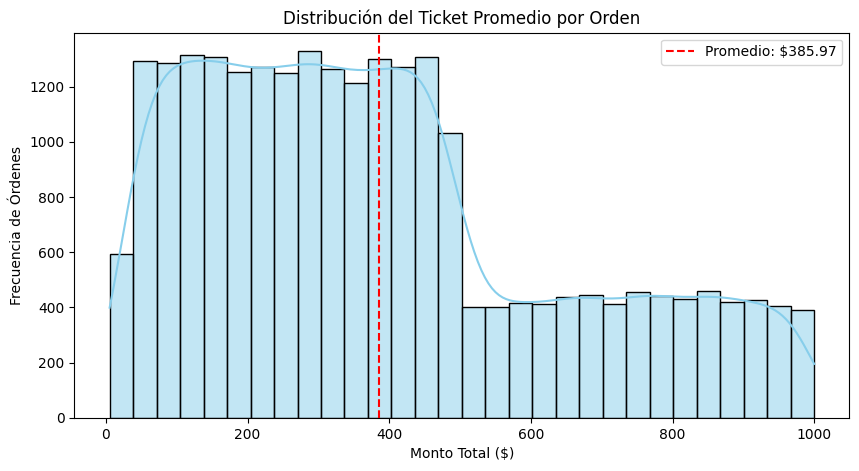

In [42]:
ticket_distribucion = orders_analisis.groupby('id_pedido')['monto_total'].sum()

plt.figure(figsize=(10, 5))
sns.histplot(ticket_distribucion, bins=30, kde=True, color='skyblue')
plt.axvline(ticket_promedio, color='red', linestyle='--', label=f'Promedio: ${ticket_promedio:,.2f}')
plt.title('Distribución del Ticket Promedio por Orden')
plt.xlabel('Monto Total ($)')
plt.ylabel('Frecuencia de Órdenes')
plt.legend()
plt.show()

### 1. Hallazgos Clave de la Distribución
* La gran mayoría de las órdenes se concentran de manera masiva y uniforme entre los 50 y los 500, manteniendo una frecuencia constante de más de 1,200 órdenes por segmento. 
* Justo al alcanzar la barrera de los 500, se observa una caída drástica y vertical en la cantidad de pedidos, cayendo a un promedio de solo ~400 órdenes por segmento.
  
* Pasando los 500, el volumen de compras se estabiliza nuevamente de forma uniforme, pero a una escala tres veces menor que el primer bloque.

### 2. Interpretación de Negocio (Hipótesis)
Este patrón tan marcado no es casualidad y usualmente responde a factores del entorno o reglas de la plataforma:

* Es muy probable que existan promociones, cupones de descuento o beneficios como "envío gratis" que tengan un tope o requieran una compra mínima cercana a los 500, lo que genera que los usuarios calibren sus carritos intencionalmente para no rebasar o quedarse justo en ese límite.
  
*  Podría indicar dos tipos de clientes o canastas: aquellos que compran productos estándar/básicos (gama baja-media por debajo de 500) y un grupo más reducido y selecto que adquiere productos premium por encima de 500.

### 3. Recomendaciones Estratégicas
1. Se sugiere diseñar una estrategia específicamente dirigida a carritos que sumen entre 400 y 450, ofreciendo un incentivo atractivo como: *"Agrega \$70 más y recibe un regalo" para empujar activamente a los usuarios a cruzar la barrera de los 500.
2. Analizar si hay alguna fricción técnica, impuesto o cobro de envío que se dispare al pasar los 500 y que esté ahuyentando un volumen importante de compras más grandes.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para el paso 2 lo ideal sería revisar las variables con gráficas siguiendo el objetivo del paso y lo que le interesa a la empresa revisar. Siempre una gráfica es mucho mejor que sólo mostrar valores numéricos, por ejemplo para la pregunta del ticket promedio podrías también mostrar la distribución ticket usando un histograma y así con el resto de preguntas escogiendo la visualización adecuada del aso.
</div>

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [43]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [44]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [45]:

# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT 
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
WHERE nombre_evento IN ('first_visit', 'add_to_cart', 'add_payment_info', 'purchase')
GROUP BY nombre_evento;
'''

totals = pd.read_sql(query_totals, con=engine)
totals


,nombre_evento,usuarios_unicos
0,add_payment_info,6250
1,add_to_cart,7634
2,first_visit,7796
3,purchase,6240


In [46]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH funnel_counts AS ( 
	SELECT 
		nombre_evento, 
		COUNT(DISTINCT id_usuario) AS usuarios_unicos 
FROM events 
WHERE nombre_evento IN ('first_visit', 'add_to_cart', 'add_payment_info', 'purchase') GROUP BY nombre_evento 
),

ordered_funnel AS ( 
 SELECT nombre_evento, usuarios_unicos, 
	CASE 
		WHEN nombre_evento = 'first_visit' THEN 1 
		WHEN nombre_evento = 'add_to_cart' THEN 2 
		WHEN nombre_evento = 'add_payment_info' THEN 3 
		WHEN nombre_evento = 'purchase' THEN 4 
	END as orden_flujo
FROM funnel_counts 
)

SELECT 
	nombre_evento, 
	usuarios_unicos, 
	ROUND(100.0 * usuarios_unicos / LAG(usuarios_unicos, 1, usuarios_unicos) OVER (ORDER BY orden_flujo), 2) AS conversion_paso_anterior_pct, 
    ROUND(100.0 * usuarios_unicos / FIRST_VALUE(usuarios_unicos) OVER (ORDER BY orden_flujo), 2) AS conversion_global_pct 
FROM ordered_funnel 
ORDER BY orden_flujo;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,nombre_evento,usuarios_unicos,conversion_paso_anterior_pct,conversion_global_pct
0,first_visit,7796,100.00,100.00
1,add_to_cart,7634,97.92,97.92
2,add_payment_info,6250,81.87,80.17
3,purchase,6240,99.84,80.04


### 1. Hallazgos Principales del Flujo
* `first_visit` a `add_to_cart`: El **97.92%** de los usuarios que visitan el sitio por primera vez añaden un producto al carrito. Esto demuestra una intención de compra extremadamente alta y que la oferta inicial es sumamente atractiva y clara.
* `add_to_cart` a `add_payment_info`: Aquí se observa la mayor caída del embudo. El **81.87%** de los usuarios que tienen un carrito deciden ingresar sus datos de pago. Aunque sigue siendo una cifra excelente, representa una pérdida de un **~18%** de usuarios en este paso intermedio.
* `add_payment_info` a `purchase`: De los 6,250 usuarios que ingresaron su información de pago, 6,240 completaron la compra. Esto equivale a una conversión del **99.84%** en el último paso; prácticamente nadie que inicia el pago abandona la plataforma.

### 2. Conversión Global
* El embudo concluye con una **conversión global del 80.04%**. Es decir, de cada 100 usuarios que entran al sitio, 80 terminan realizando una transacción monetaria. Esto indica una experiencia de usuario (UX) sumamente fluida y una audiencia altamente calificada.

### 3. Recomendaciones Estratégicas para el Negocio
1.  Dado que el único paso con una caída notable (~18%) es entre el carrito y la información de pago, se sugiere revisar si hay costos de envío sorpresa, fricción en el formulario o falta de métodos de pago populares que detengan a ese grupo de usuarios.
2. La bajísima pérdida en el último paso (solo 10 usuarios abandonaron al pagar) demuestra que la pasarela de pagos funciona de manera robusta y sin errores técnicos.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

EL cálculo de las conversiones se realizó de manera adecuada! 

Lo único que haría falta es que redactes tu propio análisis de cada uno de los resultados que estás presentando, esto lo deberías hacer en una celda markdown.
</div>

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [87]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [88]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT * 
FROM user_activity 
LIMIT 3;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [48]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohort_inicial AS (
  
    SELECT 
        TO_CHAR(CAST(fecha_registro AS DATE), 'YYYY-MM') AS cohorte,
        COUNT(DISTINCT id_usuario) AS clientes_iniciales
    FROM users
    GROUP BY TO_CHAR(CAST(fecha_registro AS DATE), 'YYYY-MM')
),
conteos_retencion AS (
   
    SELECT 
        TO_CHAR(CAST(u.fecha_registro AS DATE), 'YYYY-MM') AS cohorte,
        COUNT(DISTINCT CASE WHEN a.dias_despues_registro = 7 AND a.activo = 1 THEN a.id_usuario END) AS retenido_w1,
        COUNT(DISTINCT CASE WHEN a.dias_despues_registro = 14 AND a.activo = 1 THEN a.id_usuario END) AS retenido_w2,
        COUNT(DISTINCT CASE WHEN a.dias_despues_registro = 21 AND a.activo = 1 THEN a.id_usuario END) AS retenido_w3
    FROM user_activity a
    JOIN users u ON a.id_usuario = u.id_usuario
    GROUP BY TO_CHAR(CAST(u.fecha_registro AS DATE), 'YYYY-MM')
)

SELECT 
    c.cohorte,
    c.clientes_iniciales,
    r.retenido_w1,
    r.retenido_w2,
    r.retenido_w3,
    
    ROUND(100.0 * r.retenido_w1 / c.clientes_iniciales, 2) AS semana_1,
    ROUND(100.0 * r.retenido_w2 / c.clientes_iniciales, 2) AS semana_2,
    ROUND(100.0 * r.retenido_w3 / c.clientes_iniciales, 2) AS semana_3
FROM cohort_inicial c
LEFT JOIN conteos_retencion r ON c.cohorte = r.cohorte
ORDER BY c.cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,clientes_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01,1627,697,668,656,42.84,41.06,40.32
1,2025-02,1444,611,609,635,42.31,42.17,43.98
2,2025-03,1636,677,705,690,41.38,43.09,42.18
3,2025-04,1606,680,697,663,42.34,43.40,41.28
4,2025-05,1687,695,676,706,41.20,40.07,41.85


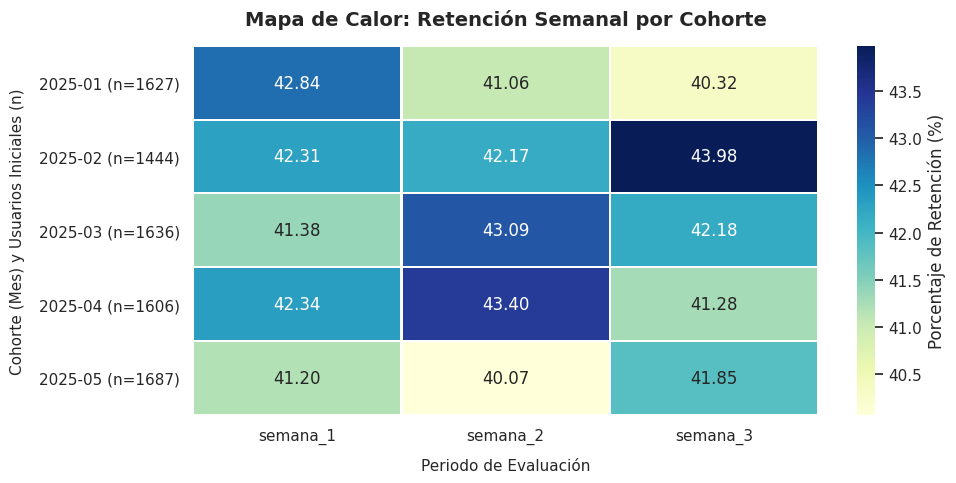

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


cohorte_final['etiqueta_eje_y'] = (
    cohorte_final['cohorte']
    + ' (n='
    + cohorte_final['clientes_iniciales'].astype(str)
    + ')'
)

df_heatmap = cohorte_final.set_index('etiqueta_eje_y')

df_retencion = df_heatmap[['semana_1', 'semana_2', 'semana_3']]

plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

ax = sns.heatmap(
    df_retencion,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.8,
    cbar_kws={'label': 'Porcentaje de Retención (%)'},
)

plt.title(
    'Mapa de Calor: Retención Semanal por Cohorte',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Periodo de Evaluación', fontsize=11, labelpad=10)
plt.ylabel(
    'Cohorte (Mes) y Usuarios Iniciales (n)', fontsize=11, labelpad=10
)  
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


1. **La Cohorte (2025-02):**
   * Es el grupo con el comportamiento más saludable a mediano plazo. A pesar de iniciar con un **42.31%** en la `semana_1`, muestra un incremento atípico hacia la `semana_3` alcanzando un **43.98%**. Esto sugiere una excelente campaña de reactivación en dicho periodo.

2. **Semana 1:**
   * Todas las cohortes muestran una retención inicial muy consistente, oscilando en un rango estrecho entre el **41.20%** (mayo) y el **42.84%** (enero). La experiencia de onboarding se mantiene homogénea.

3. **Cohorte (2025-05):**
   * La cohorte de mayo muestra una caída pronunciada en la `semana_2`, descendiendo al **40.07%** (el punto más bajo registrado en todo el gráfico). Sin embargo, se recupera en la `semana_3` subiendo al **41.85%**, lo que indica que el problema es crítico principalmente en los días inmediatos posteriores al registro.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Perfecto la query y los resultados presentados. Lo único que recomendaría aquí es tratar de llevarlo a algo más visual para que sea más fácil de explicar y entender
</div>

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---


Hipótesis estadística
   - **H₀ (Hipótesis nula):** La nueva UI no tiene impacto en la tasa de conversión. La conversión del grupo de tratamiento es igual a la del grupo de control. Cualquier diferencia observada se debe al azar.
   - **H₁ (Hipótesis alternativa):** La nueva UI sí tiene un impacto significativo en la tasa de conversión
   
**Test estadístico:** Z-statistic: $-0.8133$        
P-value: 0.4161 
Dado que el P-value 0.4161 es significativamente mayor que el nivel de significancia establecido alpha = 0.05, no contamos con evidencia estadística para rechazar la hipótesis nula. La diferencia observada a favor del grupo de tratamiento se atribuye por completo al azar y a la variabilidad natural del tráfico.

**Nivel de significancia alpha:** (5%). 




In [90]:
# tu código aquí
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest


In [91]:
df_exp = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

In [92]:
resumen_test = df_exp.groupby('variante')['convirtio'].agg(['sum', 'count']).rename(
    columns={'sum': 'exitos_conversiones', 'count': 'total_observaciones'}
)

In [93]:
print(df_exp.columns)

Index(['id_usuario', 'variante', 'convirtio', 'dispositivo', 'pais',
       'duracion_sesion', 'timestamp'],
      dtype='object')


In [94]:
resumen_test['tasa_conversion(%)'] = (resumen_test['exitos_conversiones'] / resumen_test['total_observaciones']) * 100

print("=========================================================================")
print("DATOS AGREGADOS PARA EL Z-TEST")
print(resumen_test)

exitos = resumen_test['exitos_conversiones'].values
observaciones = resumen_test['total_observaciones'].values

z_stat, p_value = proportions_ztest(count=exitos, nobs=observaciones, alternative='two-sided')

print(f" Z-statistic: {z_stat:.4f}")
print(f" P-value:     {p_value:.6f}")

DATOS AGREGADOS PARA EL Z-TEST
             exitos_conversiones  total_observaciones  tasa_conversion(%)
variante                                                                 
control                      779                 4965           15.689829
tratamiento                  820                 5035           16.285998
 Z-statistic: -0.8133
 P-value:     0.416059


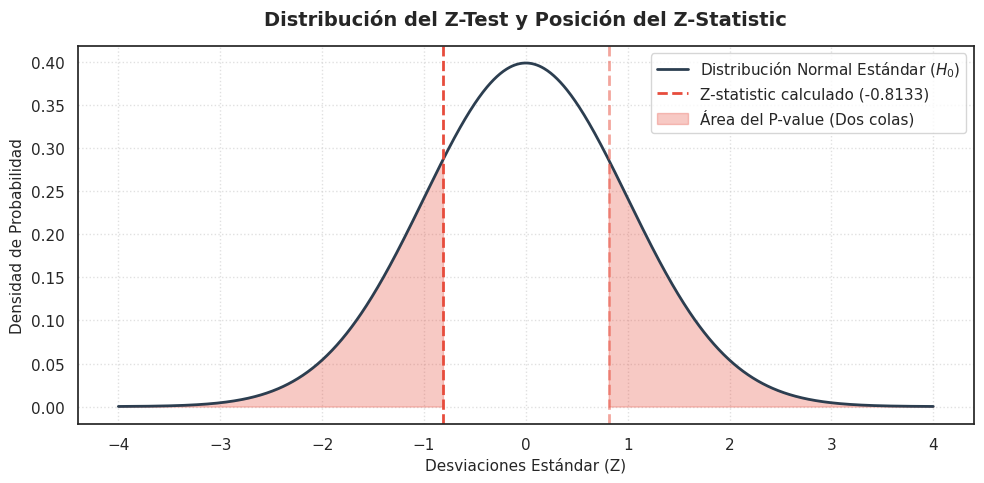

In [54]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

plt.figure(figsize=(10, 5))
plt.rcParams.update({'font.family': 'sans-serif'})

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, 0, 1)
plt.plot(x, y, label='Distribución Normal Estándar ($H_0$)', color='#2c3e50', lw=2)

z_calculado = -0.8133 

plt.axvline(z_calculado, color='#e74c3c', linestyle='--', lw=2, 
            label=f'Z-statistic calculado ({z_calculado:.4f})')
plt.axvline(-z_calculado, color='#e74c3c', linestyle='--', lw=2, alpha=0.5)

x_cola_izq = np.linspace(-4, z_calculado, 100)
plt.fill_between(x_cola_izq, norm.pdf(x_cola_izq, 0, 1), color='#e74c3c', alpha=0.3, 
                 label='Área del P-value (Dos colas)')

x_cola_der = np.linspace(-z_calculado, 4, 100)
plt.fill_between(x_cola_der, norm.pdf(x_cola_der, 0, 1), color='#e74c3c', alpha=0.3)

plt.title('Distribución del Z-Test y Posición del Z-Statistic', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Desviaciones Estándar (Z)', fontsize=11)
plt.ylabel('Densidad de Probabilidad', fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Para que una diferencia sea considerada estadísticamente significativa (con un nivel de confianza del $95\%$), la línea roja tendría que haber caído en los extremos lejanos de la campana (más allá de -1.96 o 1.96), donde la curva es casi plana.Como la línea roja quedó atrapada "dentro" de la zona central de la campana y las áreas sombreadas son extensas, el gráfico demuestra de forma matemática y visual que el experimento no tuvo un impacto real y el cambio observado se debe al azar.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [ ]:
# (Pega aquí tu link)
# link de power bi o tableau
# https://drive.google.com/drive/folders/1wE59NWVNpfDCgGhA_M1CmbuzjZPzYSRu?usp=sharing

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen avance de tu proyecto en cuanto a código Ilich, pero hace falta la parte de story telling que cómo profesional de datos siempre se debe tener. Es decir, usando celdas markdown se debe ir redactando el análisis que vas realizando de los diferentes resultados y de esta forma comunicar de manera adecuada que es lo que se está analizando y por qué.

También, al final deberías tener una sección con conclusiones y recomendaciones generales que puedas darle a la empresa en base a los diferentes pasos realizados a lo largo de tu notebook.

Si tienes dudas o dificultades recuerda que puedes contactar a tu Success Manager o a tu tutor para solventarlas.

Saludos!
</div>